# <p style="text-align: center; font-size: 2.5rem">Notebook V</p>

<p style="text-align: center; font-size: 2rem">Plankton Density Imputation with Prophet</p>

This notebook uses Facebook Prophet to fit time series models on sparse COPEPOD plankton data per spatial region, impute continuous density values, and merge the results into the strandings dataset.

**Prerequisites**: Run `01_c_plankton_data_clean.ipynb` first to generate `copepod_dataset_se_coast.parquet`.


## Notebook Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import logging

# Enable logging from the plankton module
logging.basicConfig(level=logging.INFO)

from se_coast_strandings.transformations import make_dt_col
from se_coast_strandings import make_degrees
from se_coast_strandings.contextual_data.plankton_abundance import (
    assign_region,
    prepare_prophet_series,
    fit_and_impute,
    build_plankton_lookup,
    merge_plankton_to_strandings,
)

In [2]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Actual plankton count-per-volume column (renamed from VALUE-per-volu in 01_c)
VALUE_COL = "count"

# Time series frequency: 'W' = weekly, 'MS' = monthly start
FREQ = "W"

# ── Region tuning ────────────────────────────────────────────────────────────
# Must match DEGREES_PER_BAND used in notebooks 06/09/10 so regions align.
DEGREES_PER_BAND = 0.5
REGIONS = make_degrees(DEGREES_PER_BAND)

## Step 1: Load and Prepare the Plankton Data


In [3]:
plankton_df = pd.read_parquet(PROCESSED_DIR / "copepod_dataset_se_coast.parquet")

# Recompute date from the correct lowercase columns (the stored 'date' column is corrupt)
plankton_df["date"] = make_dt_col(plankton_df["day"], plankton_df["month"], plankton_df["year"])

# Drop rows without valid dates or plankton values
plankton_df = plankton_df.dropna(subset=["date", VALUE_COL])

print(f"Plankton data: {plankton_df.shape[0]:,} rows")
print(f"Date range: {plankton_df['date'].min()} to {plankton_df['date'].max()}")
plankton_df.head()

Plankton data: 34,495 rows
Date range: 1953-02-16 00:00:00 to 2001-12-08 00:00:00


,year,month,day,time_gmt,time_local,lat,lon,upper_z,lower_z,grouping_code,...,VALUE-per-area,VALUE-per_area-UNITS,VALUE-per-area-F1,VALUE-per-area-F2,VALUE-per-area-F3,VALUE-per-area-F4,SCIENTIFIC NAME -[ modifiers ]-,RECORD-ID,DATASET-ID,date
0,1995,3,19,11.600,-99.0,40.047,-69.477,10.0,10.0,4320000,...,null,-----,-1,-1,-1,-1,"Chaetognatha ""CPR-TOTAL """"eyecount""""""",0008_0001,SAHFOS-CPR Atlantic Ocean,1995-03-19
1,1995,4,16,3.367,-99.0,40.113,-69.375,10.0,10.0,4212000,...,null,-----,-1,-1,-1,-1,Copepoda TOTAL (total count),0020_0005,SAHFOS-CPR Atlantic Ocean,1995-04-16
2,1995,4,16,3.367,-99.0,40.113,-69.375,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,"Calanus ""CPR-TOTAL """"traverse""""""",0020_0004,SAHFOS-CPR Atlantic Ocean,1995-04-16
3,1995,4,16,3.367,-99.0,40.113,-69.375,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,Calanus TOTAL (total count) -[ c5-6 ]-,0020_0007,SAHFOS-CPR Atlantic Ocean,1995-04-16
4,1995,4,16,3.367,-99.0,40.113,-69.375,10.0,10.0,4212010,...,null,-----,-1,-1,-1,-1,Calanus -[ c1-4 ]-,0020_0001,SAHFOS-CPR Atlantic Ocean,1995-04-16


## Step 2: Assign Spatial Regions

Each observation is assigned to a latitude-band region covering the SE coast.


In [4]:
plankton_df["region"] = assign_region(plankton_df["lat"])

print("Observations per region:")
print(plankton_df["region"].value_counts().to_string())
print(f"\nUnassigned: {plankton_df['region'].isna().sum():,}")

Observations per region:
region
SC          4886
NC-south    3009
VA          2408
NC-north     567

Unassigned: 23,625


## Step 3: Explore the Time Series per Region

Before fitting Prophet, let's see what the weekly aggregated series look like.


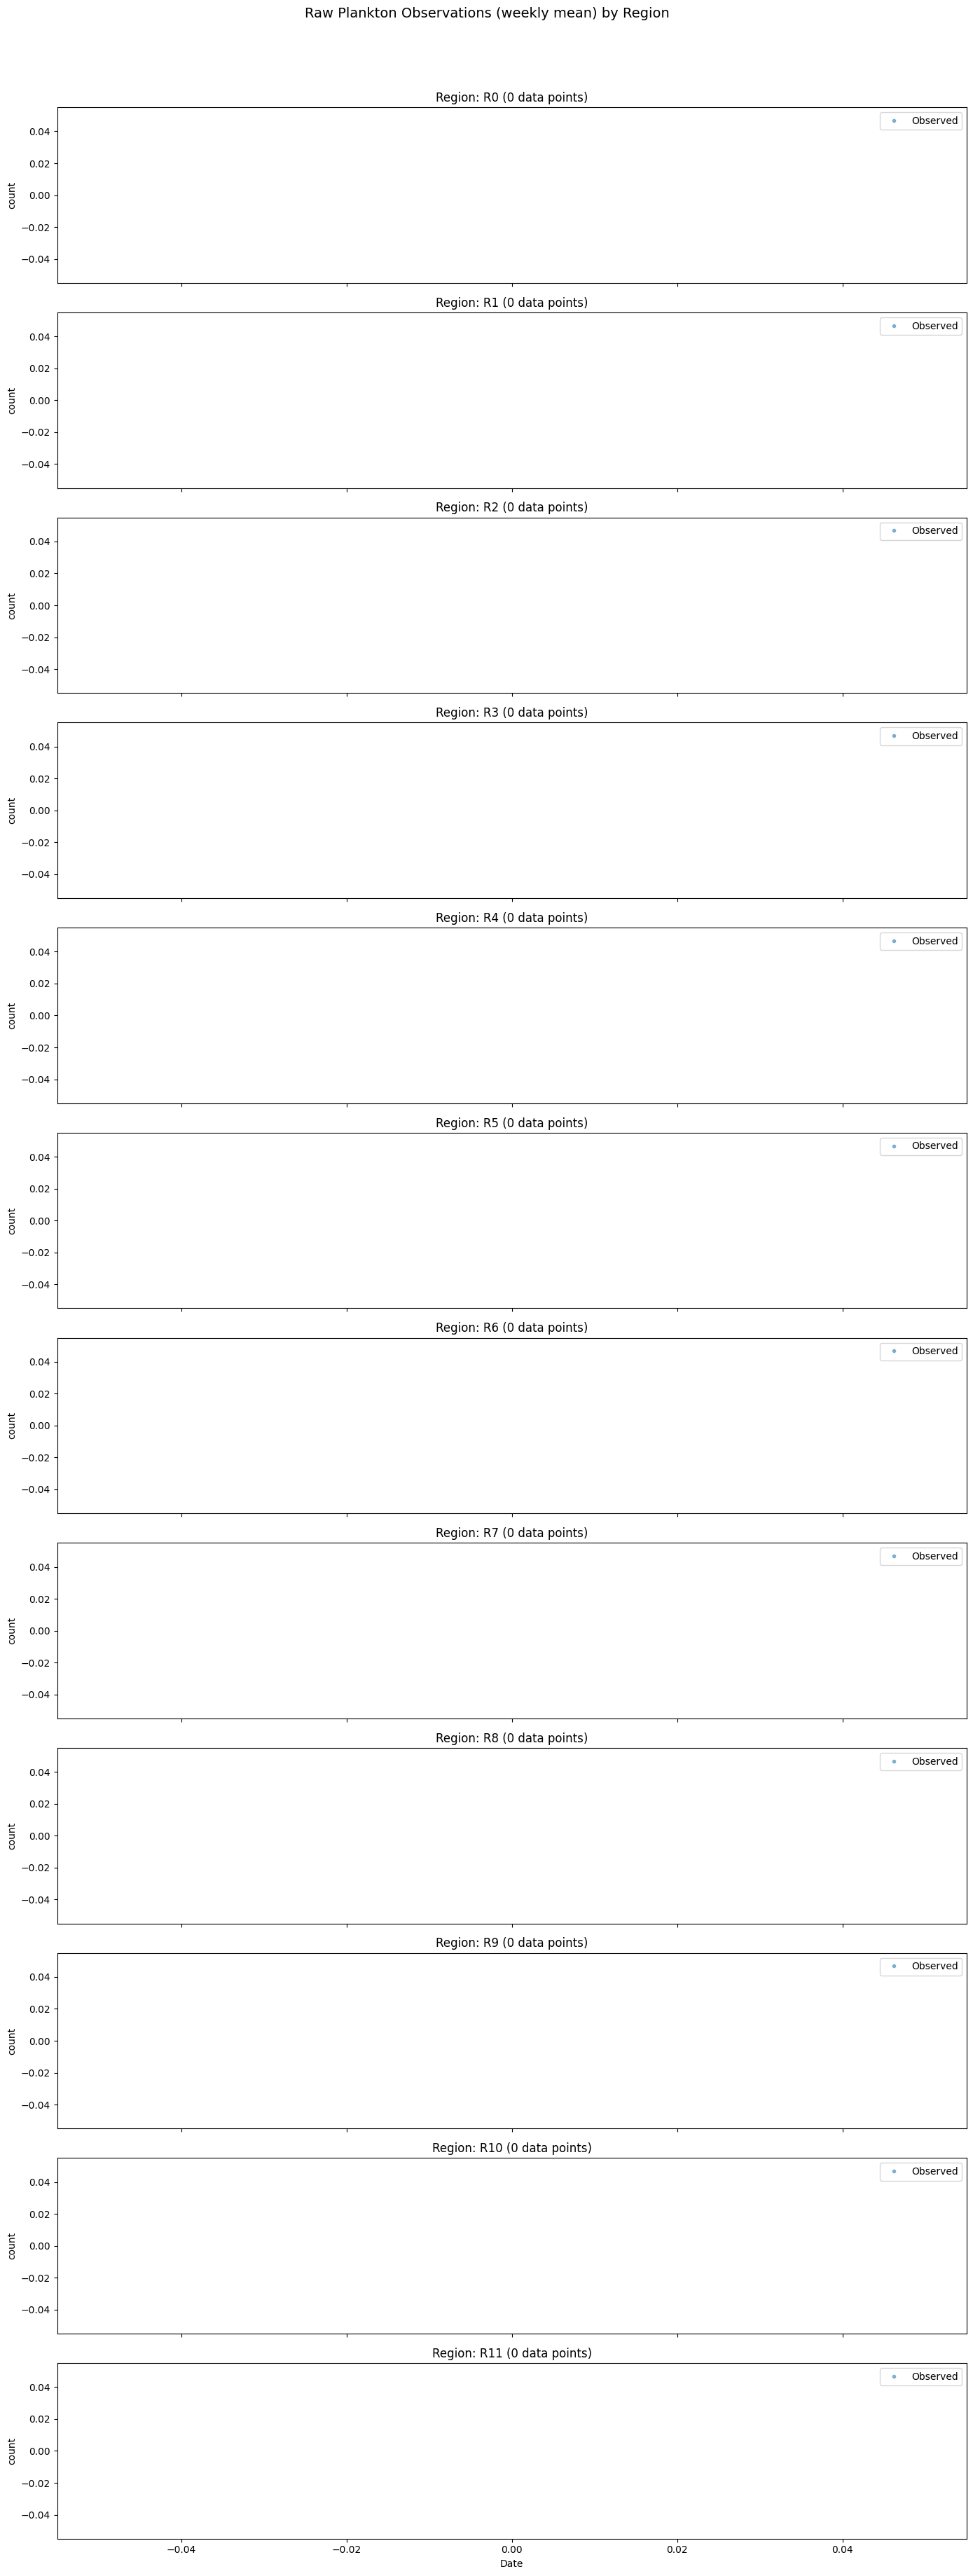

In [5]:
fig, axes = plt.subplots(len(REGIONS), 1, figsize=(14, 3 * len(REGIONS)), sharex=True)

for ax, (label, _, _) in zip(axes, REGIONS):
    prophet_series = prepare_prophet_series(
        plankton_df, region=label, date_col="date", value_col=VALUE_COL, freq=FREQ
    )
    valid = prophet_series.dropna(subset=["y"])

    ax.plot(valid["ds"], valid["y"], "o", markersize=3, alpha=0.5, label="Observed")
    ax.set_title(f"Region: {label} ({len(valid)} data points)")
    ax.set_ylabel(VALUE_COL)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Date")
fig.suptitle("Raw Plankton Observations (weekly mean) by Region", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Step 4: Build the Full Plankton Lookup Table

This runs `build_plankton_lookup` which:
1. Assigns regions
2. Aggregates to weekly
3. Fits a Prophet model per region
4. Generates predictions over the full date range

This may take a few minutes.


In [6]:
lookup = build_plankton_lookup(
    plankton_df,
    value_col=VALUE_COL,
    date_col="date",
    lat_col="lat",
    regions=REGIONS,
    freq=FREQ,
    forecast_end="2025-12-31",
)

print(f"Lookup table: {lookup.shape[0]:,} rows")
print(f"Regions: {lookup['region'].unique().tolist()}")
print(f"Date range: {lookup['ds'].min()} to {lookup['ds'].max()}")
lookup.head(10)

INFO:se_coast_strandings.contextual_data.plankton_abundance:Fitting Prophet model for region: R0
ERROR:prophet.plot:Importing plotly failed. Interactive plots will not work.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:se_coast_strandings.contextual_data.plankton_abundance:Fitting Prophet model for region: R1
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:se_coast_strandings.contextual_data.plankton_abundance:Fitting Prophet model for region: R2
INFO:prophet:n_changepoints greater than number of observations. Using 9.
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:se_coast_strandings.contextual_data.plankton_abundance:Fitting Prophet model for region: R3
INFO:prophet:n_changepoints greater than number of observations

Lookup table: 34,209 rows
Regions: ['R0', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R10', 'R11']
Date range: 1953-03-01 00:00:00 to 2025-12-28 00:00:00


,ds,yhat,yhat_lower,yhat_upper,region
0,1953-03-01,51.693339,51.693339,51.693339,R0
1,1953-03-08,9052.440816,9052.440816,9052.440816,R0
2,1953-03-15,20549.913948,20549.913948,20549.913948,R0
3,1953-03-22,21853.636373,21853.636373,21853.636373,R0
4,1953-03-29,13645.708088,13645.708088,13645.708088,R0
5,1953-04-05,8993.190512,8993.190512,8993.190512,R0
6,1953-04-12,15227.182931,15227.182931,15227.182931,R0
7,1953-04-19,23887.518709,23887.518709,23887.518709,R0
8,1953-04-26,22200.152303,22200.152303,22200.152303,R0
9,1953-05-03,10135.945753,10135.945753,10135.945753,R0


## Step 5: Visualize the Imputed Results

Overlay Prophet's imputed values on top of the original observations.


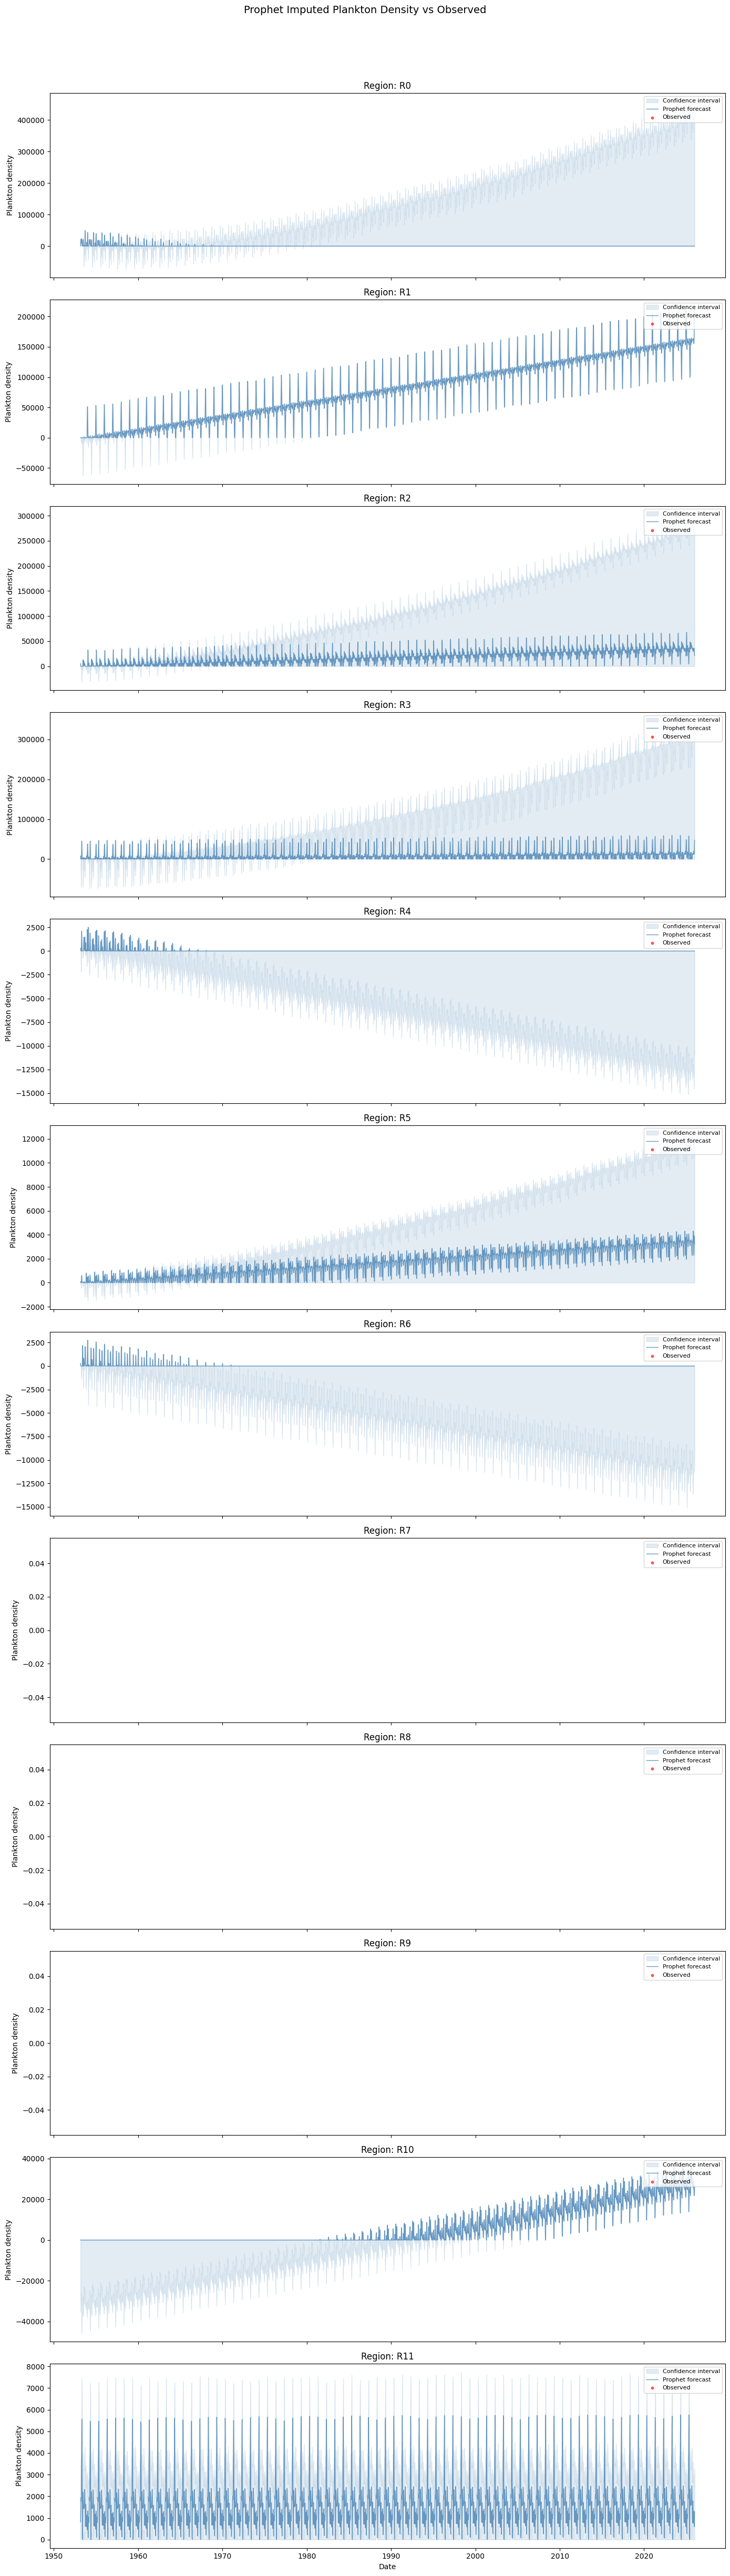

In [7]:
fig, axes = plt.subplots(len(REGIONS), 1, figsize=(14, 4 * len(REGIONS)), sharex=True)

for ax, (label, _, _) in zip(axes, REGIONS):
    # Original observations
    raw = prepare_prophet_series(
        plankton_df, region=label, date_col="date", value_col=VALUE_COL, freq=FREQ
    ).dropna(subset=["y"])

    # Prophet forecast
    forecast = lookup[lookup["region"] == label]

    # Plot confidence interval
    ax.fill_between(
        forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
        alpha=0.15, color="steelblue", label="Confidence interval"
    )

    # Plot forecast line
    ax.plot(forecast["ds"], forecast["yhat"], "-", color="steelblue",
            linewidth=1, alpha=0.8, label="Prophet forecast")

    # Plot original observations
    ax.scatter(raw["ds"], raw["y"], s=10, color="red", alpha=0.6,
               zorder=5, label="Observed")

    ax.set_title(f"Region: {label}")
    ax.set_ylabel("Plankton density")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Date")
fig.suptitle("Prophet Imputed Plankton Density vs Observed", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "plankton_imputation_by_region.png", dpi=200, bbox_inches="tight")
plt.show()

## Step 6: Save the Lookup Table


In [8]:
lookup.to_parquet(PROCESSED_DIR / "plankton_imputed_lookup.parquet", index=False)
print("Saved: data/processed/plankton_imputed_lookup.parquet")

Saved: data/processed/plankton_imputed_lookup.parquet


## Step 7: Merge Plankton Density into Strandings

Load the strandings data and attach plankton density to each stranding event.


In [9]:
# Load strandings
strandings_df = pd.read_excel(
    RAW_DIR / "UNC-DataRequest-01302026.xlsx", sheet_name="2015-2024"
)

# Create datetime column
strandings_df["mms_observation_dt"] = make_dt_col(
    strandings_df["Day of Observation"],
    strandings_df["Month of Observation"],
    strandings_df["Year of Observation"],
)

# Clean coordinates
strandings_df["Latitude"] = pd.to_numeric(strandings_df["Latitude"], errors="coerce")
strandings_df["Longitude"] = pd.to_numeric(strandings_df["Longitude"], errors="coerce")
strandings_df = strandings_df.dropna(subset=["Latitude", "Longitude", "mms_observation_dt"])

print(f"Strandings: {strandings_df.shape[0]:,} rows")
strandings_df.head()

Strandings: 2,547 rows


,National Database Number,Confidence Code,Common Name,Genus,Species,County,State,Latitude,Latitude Units,Latitude Actual/Estimate,...,Weight,Weight Units,Weight actual/estimate,Dead Animal Exam,Extent of Exam,Necropy Carcass Fresh/Frozen,Date of Exam,Additional Remarks,Report Type,mms_observation_dt
0,SE-2024-1283198,Confirmed Public Report,"Dolphin, bottlenose",Tursiops,truncatus,Charleston,SC,32.753987,decimal degrees,actual,...,NaN,NaN,notMeasured,N,NaN,NaN,NaN,Stranded alive. Pushed back to sea by public. ...,NaN,2024-07-20
1,SE-2016-1185796,Confirmed - High Report,"Dolphin, bottlenose",Tursiops,truncatus,Carteret,NC,35.014470,decimal degrees,actual,...,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,2016-05-27
2,SE-2016-1185799,Confirmed - High Report,"Dolphin, bottlenose",Tursiops,truncatus,Hyde,NC,35.428380,decimal degrees,actual,...,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,2016-05-28
3,SE-2021-1236490,Confirmed - Minimum,"Dolphin, bottlenose",Tursiops,truncatus,Charleston,SC,32.657583,decimal degrees,actual,...,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,2021-06-19
4,SE-2021-1236491,Confirmed - High Report,"Dolphin, bottlenose",Tursiops,truncatus,Charleston,SC,32.674153,decimal degrees,actual,...,NaN,NaN,NaN,Y,complete,fresh,2021-Jun-29,NaN,NaN,2021-06-29


In [10]:
enriched = merge_plankton_to_strandings(
    strandings_df,
    lookup,
    stranding_date_col="mms_observation_dt",
    stranding_lat_col="Latitude",
)

print(f"Enriched strandings: {enriched.shape[0]:,} rows")
print(f"\nPlankton density coverage:")
print(f"  Has value: {enriched['plankton_density'].notna().sum():,}")
print(f"  Missing:   {enriched['plankton_density'].isna().sum():,}")
print(f"\nBy region:")
print(enriched["plankton_region"].value_counts().to_string())

Enriched strandings: 2,547 rows

Plankton density coverage:
  Has value: 0
  Missing:   2,547

By region:
plankton_region
VA          1068
NC-north     702
SC           492
NC-south     278


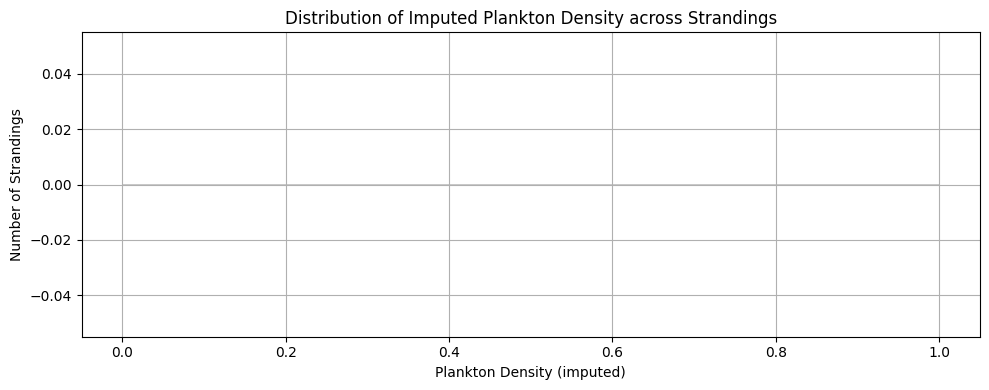

In [11]:
# Quick sanity check: plankton density distribution
fig, ax = plt.subplots(figsize=(10, 4))
enriched["plankton_density"].hist(bins=50, ax=ax, color="teal", edgecolor="black", linewidth=0.3)
ax.set_title("Distribution of Imputed Plankton Density across Strandings")
ax.set_xlabel("Plankton Density (imputed)")
ax.set_ylabel("Number of Strandings")
plt.tight_layout()
plt.show()

## Step 8: Save the Enriched Strandings Dataset


In [12]:
enriched.to_parquet(PROCESSED_DIR / "strandings_with_plankton.parquet", index=False)
print("Saved: data/processed/strandings_with_plankton.parquet")

Saved: data/processed/strandings_with_plankton.parquet
